# Projet ML — Prédiction de la direction du Bitcoin

**Cours :** Introduction au Machine Learning — L3 Dauphine  
**Auteurs :** *(à compléter)*

---

## 1. Présentation du projet

Les cryptomonnaies, et le Bitcoin en particulier, sont des actifs très volatils dont l'évolution dépend de nombreux facteurs (sentiment de marché, actualités, flux de capitaux, etc.). Une question naturelle est de savoir si l'on peut, à partir uniquement de l'historique des prix et des volumes, prédire le cours du bitcoin.

### Problématique
**Peut-on prédire si le cours du Bitcoin va monter ou baisser à partir de variables construites sur son historique récent ?**

### Définition du problème

D'abord il est nécessaire de définir précisément ce qui est entendu par "prédire le cours du bitcoin". Notre objectif est de savoir à un jour $t$, s'il est intéressant d'acheter ou de vendre. Pour cela on aimerait prédire si le cours va augmenter ou diminuer (disons sur les 24h suivant).

Nous considérerons que d'un jour $t$ à un jour $(t+1)$ le cours du Bitcoin augmente (resp diminue) si sa valeur à la clôture au jour $t$ est inférieure (resp supérieure) à sa valeur à la clôture au jour $(t+1)$. 

Ainsi à partir d'un ensemble de variables calculée au jours $t$ on cherchera à prédire si $\text{Close}_{t+1} > \text{Close}_{t}$.

Il s'agit d'un problème de **classification binaire supervisée** :
- $X$ : ensemble de variables (rendements passés, moyennes mobiles, volatilité, volume…) calculées au jour $t$
- $y \in \{0, 1\}$ : 1 si $\text{Close}_{t+1} > \text{Close}_{t}$ (hausse), 0 sinon (baisse)

### Données
Dataset Kaggle : *Bitcoin Historical Datasets 2018-2024* (Novandra Anugrah).  
Lien : https://www.kaggle.com/datasets/novandraanugrah/bitcoin-historical-datasets-2018-2024

Nous utilisons le fichier **journalier** (`btc_1d_data_2018_to_2025.csv`) qui contient les colonnes OHLCV (Open, High, Low, Close, Volume) du BTC/USDT sur Binance.

### Méthodologie
1. Exploration et nettoyage des données
2. Construction de variables (*feature engineering*)
3. Visualisation par ACP
4. Comparaison de plusieurs modèles : régression logistique, régression logistique pénalisée (Ridge / Lasso) et KNN
5. Choix du modèle final par validation croisée
6. Évaluation sur un jeu de test chronologique
7. Test de généralisation sur d'autres cryptomonnaies (ETH, SOL)
8. Discussion et perspectives

## 2. Imports et configuration

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
)

#Affichage
plt.rcParams['figure.figsize'] = (10, 5) #taille par defaut des graphiques
pd.set_option('display.max_columns', 50) #affichage des tableaux
np.random.seed(42) #initialisation de la seed pour les processus aléatoires np

## 3. Chargement et exploration des données

Le dataset contient une ligne par jour avec les prix d'ouverture, plus haut, plus bas, de clôture et le volume échangé.

In [49]:
DATA_PATH = "data/btc_1d_data_2018_to_2025.csv"

df = pd.read_csv(DATA_PATH)

# Conversion de la date et tri chronologique
df['Open time'] = pd.to_datetime(df['Open time'])
df = df.sort_values('Open time').reset_index(drop=True)

#on ne garde que les colonnes utiles
df = df[['Open time', 'Open', 'High', 'Low', 'Close', 'Volume']]
df = df.rename(columns={'Open time': 'Date'})

print(f"Nombre d'observations : {len(df)}")
print(f"Période : du {df['Date'].min().date()} au {df['Date'].max().date()}")
df.head()

Nombre d'observations : 2997
Période : du 2018-01-01 au 2026-03-16


,Date,Open,High,Low,Close,Volume
0,2018-01-01 00:00:00+00:00,13715.65,13818.55,12750.00,13380.00,8609.915844
1,2018-01-02 00:00:00+00:00,13382.16,15473.49,12890.02,14675.11,20078.092111
2,2018-01-03 00:00:00+00:00,14690.00,15307.56,14150.00,14919.51,15905.667639
3,2018-01-04 00:00:00+00:00,14919.51,15280.00,13918.04,15059.54,21329.649574
4,2018-01-05 00:00:00+00:00,15059.56,17176.24,14600.00,16960.39,23251.491125


In [50]:
#on vérifie si il ne manque pas des données
print("Valeurs manquantes par colonne :")
print(df.isna().sum())

Valeurs manquantes par colonne :
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


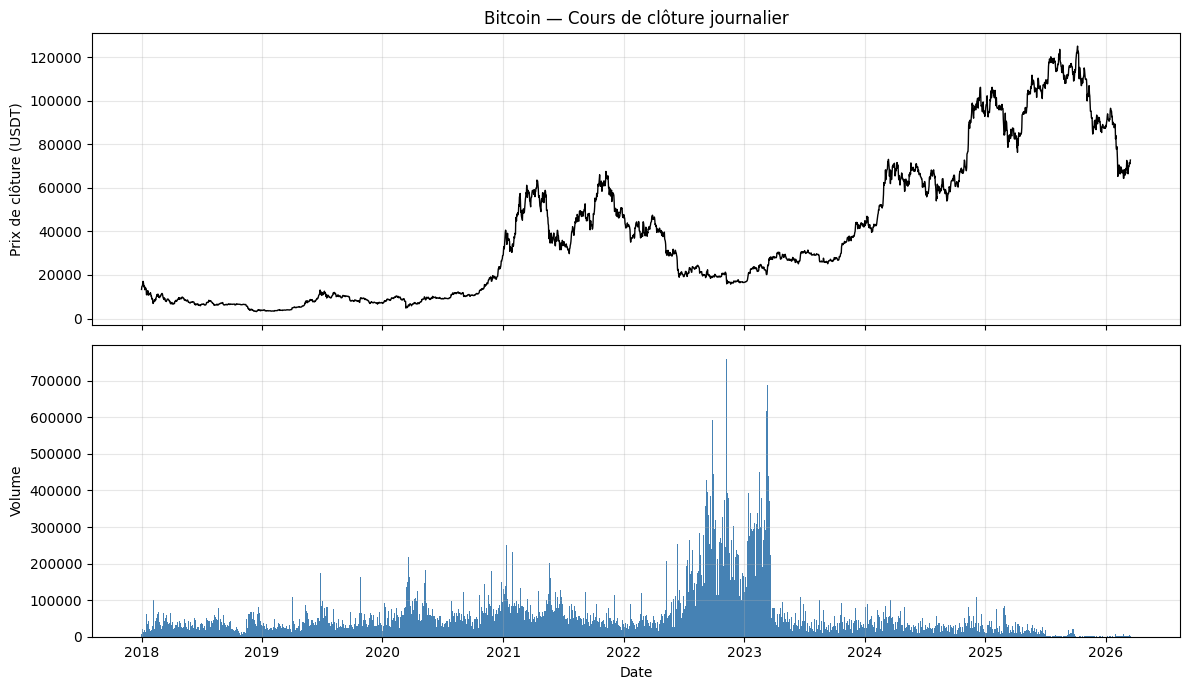

In [51]:
# Visualisation du cours de clôture et du volume
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(df['Date'], df['Close'], color='black', lw=1)
axes[0].set_ylabel("Prix de clôture (USDT)")
axes[0].set_title("Bitcoin — Cours de clôture journalier")
axes[0].grid(alpha=0.3)

axes[1].bar(df['Date'], df['Volume'], color='steelblue', width=1.0)
axes[1].set_ylabel("Volume")
axes[1].set_xlabel("Date")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

(*On observe les grandes phases du marché : la bulle de fin 2017, le bear market de 2018, le rallye 2020-2021, le crash 2022, puis la reprise. C'est typique d'une série financière : **non stationnaire**, avec de forts changements de régime*)

Remarques sur les fluctuation du volume 2022-2023

## 4. Feature engineering

Les données brutes ne sont pas directement utilisables. On ne peut pas comparer le prix du bitcoin en 2018 à celui en 2025. Nous allons donc utiliser ces données pour construire des variables plus représentatives et comparables entre elles. Nous les utiliserons ensuite pour entraîner le modèle.

### Variables construites

Nous avons choisi des variables très utilisées dans le milieu de la finance quantitative.

**Rendements passés** (variations relatives) :
$$r_t = \frac{\text{Close}_t - \text{Close}_{t-1}}{\text{Close}_{t-1}}$$
C'est la variation du prix en % sur la journée. On calculera cette variation sur différentes fenêtres : $r_{t-1}, r_{t-2}, r_{t-5}, r_{t-10}$.

**Moyennes mobiles MA20 et écart relatif** au MA20 :
$$\text{ecart\_MA20}_t = \frac{\text{Close}_t - \text{MA20}_t}{\text{MA20}_t}$$
Cet écart mesure si le prix est anormalement haut ou bas par rapport à sa tendance récente (où $\text{MA20}_t$ est la moyenne des prix de clôture sur les 20 derniers jours).

**Volatilité réalisée** (sur $N$ jours, avec $N \in \{5, 10, 20\}$) :
C'est l'estimateur de l'écart-type des rendements sur une fenêtre glissante.
$$\sigma_{N,t} = \sqrt{\frac{1}{N-1} \sum_{i=0}^{N-1} (r_{t-i} - \bar{r}_{N,t})^2}$$
*(Où $\bar{r}_{N,t}$ est la moyenne arithmétique des rendements sur la fenêtre de $N$ jours).*

Elle indique le régime actuel du marché (calme ou agité).

**Volume normalisé** :
Il s'agit du ratio du volume actuel ($V_t$) sur sa moyenne mobile à 20 jours ($\text{MA20}_{V,t}$), combiné à la variation relative journalière du volume.
$$\text{Volume\_Normalise}_t = \left(\frac{V_t}{\text{MA20}_{V,t}}\right) + \left(\frac{V_t - V_{t-1}}{V_{t-1}}\right)$$

Il évalue la conviction derrière un mouvement de prix, aidant le modèle à distinguer les véritables tendances (soutenues par une activité anormale) des faux signaux.

**Cible (Target)** :
Il s'agit du signal de classification binaire pour notre modèle prédictif.
$$y_t = \begin{cases} 1 & \text{si } \text{Close}_{t+1} > \text{Close}_t \\ 0 & \text{sinon} \end{cases}$$

In [ ]:
def construire_features(df):
    data = df.copy()
    
    # Rendements (variations relatives) du prix de clôture
    data['return_1'] = data['Close'].pct_change(1) #calcul variation en pourcentage entre le close de la veille et 
    data['return_2'] = data['Close'].pct_change(2)
    data['return_5'] = data['Close'].pct_change(5)
    data['return_10'] = data['Close'].pct_change(10)
    
    # Moyenne mobiles
    data['MA20'] = data['Close'].rolling(20).mean()
    
    # Écart relatif du prix actuel à sa moyenne mobile 20j
    data['ecart_MA20'] = (data['Close'] - data['MA20']) / data['MA20']
    
    # Volatilité réalisée (std des rendements journaliers)
    data['vol_5'] = data['return_1'].rolling(5).std()
    data['vol_10'] = data['return_1'].rolling(10).std()
    data['vol_20'] = data['return_1'].rolling(20).std()
    
    # Volume normalisé par sa moyenne mobile 20j
    data['vol_norm'] = data['Volume'] / data['Volume'].rolling(20).mean()
    data['vol_change'] = data['Volume'].pct_change(1) # pct change : rapport entre le jour meme et la veille
    
    # Cible : 1 si le prix monte demain, 0 sinon
    data['y'] = (data['Close'].shift(-1) > data['Close']).astype(int)
    
    return data

df_feat = construire_features(df)

#liste des features que l'on va utiliser pour entrainer le modèle
FEATURES = [
    'return_1', 'return_2', 'return_5', 'return_10',
    'ecart_MA20',
    'vol_5', 'vol_10', 'vol_20',
    'vol_norm', 'vol_change',
]

#on enlève les premières lignes où les rolling windows ne sont pas définies
# et la dernière ligne où y n'est pas défini (pas de jour suivant)
df_clean = df_feat.dropna(subset=FEATURES + ['y']).reset_index(drop=True)

print(f"Nombre d'observations après nettoyage : {len(df_clean)}")
print(f"Nombre de features : {len(FEATURES)}")
df_clean[['Date', 'Close'] + FEATURES + ['y']].head()

Nombre d'observations après nettoyage : 2977
Nombre de features : 10


,Date,Close,return_1,return_2,return_5,return_10,ecart_MA20,vol_5,vol_10,vol_20,vol_norm,vol_change,y
0,2018-01-21 00:00:00+00:00,11530.00,-0.099215,0.004795,0.057798,-0.129074,-0.164200,0.078251,0.086752,0.078759,1.498467,0.438353,0
1,2018-01-22 00:00:00+00:00,10760.05,-0.066778,-0.159367,-0.020816,-0.216882,-0.208786,0.086347,0.086635,0.076152,1.519268,0.057343,1
2,2018-01-23 00:00:00+00:00,10799.18,0.003637,-0.063384,-0.014850,-0.240030,-0.193694,0.086369,0.085011,0.075945,1.254278,-0.143504,1
3,2018-01-24 00:00:00+00:00,11349.99,0.051005,0.054827,-0.010892,-0.157700,-0.140668,0.086957,0.087412,0.077156,0.900235,-0.275267,0
4,2018-01-25 00:00:00+00:00,11175.27,-0.015394,0.034826,-0.126928,-0.174643,-0.134952,0.059037,0.087178,0.070062,0.693561,-0.232657,0


In [53]:
# Distribution de la cible : est-ce que les classes sont équilibrées ?
print(df_clean['y'].value_counts(normalize=True).rename({0: 'Baisse', 1: 'Hausse'}))
print(f"\nProportion de jours en hausse : {df_clean['y'].mean():.2%}")

y
Hausse    0.50823
Baisse    0.49177
Name: proportion, dtype: float64

Proportion de jours en hausse : 50.82%


Les classes sont à peu près équilibrées avec un léger biais haussier (logique sur la période 2018-2025 où le BTC a fortement progressé). Ce léger déséquilibre nous donne **un baseline naïf** : prédire toujours "hausse" donne déjà ~52-53% d'accuracy. C'est ce score que nos modèles devront battre.

## 5. Préparation du jeu de données : split chronologique

Nous avons décidé de ne pas faire de `train_test_split` aléatoire. C'est commun lorsque l'on travaille sur des séries temporelles pour ne pas mélanger le passé et le futur (et donc faire fuiter de l'information).

On fait donc un split **chronologique** : on entraîne sur les 80% premiers jours et on teste sur les 20% les plus récents.

In [54]:
X = df_clean[FEATURES].values
y = df_clean['y'].values
dates = df_clean['Date'].values

# Split chronologique 80/20
split_idx = int(len(df_clean) * 0.8) #calul indice qui coupe à 80%

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
dates_train, dates_test = dates[:split_idx], dates[split_idx:]

print(f"Train : {len(X_train)} jours  ({pd.Timestamp(dates_train[0]).date()} → {pd.Timestamp(dates_train[-1]).date()})")
print(f"Test  : {len(X_test)} jours  ({pd.Timestamp(dates_test[0]).date()} → {pd.Timestamp(dates_test[-1]).date()})")

Train : 2381 jours  (2018-01-21 → 2024-07-28)
Test  : 596 jours  (2024-07-29 → 2026-03-16)


In [55]:
# Standardisation des features (moyenne 0, écart-type 1)
# Important : on fit le scaler UNIQUEMENT sur le train pour éviter la fuite d'information
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

## 6. Visualisation par ACP

Avant de modéliser, nous allons projeter les données grâce à une **Analyse en Composantes Principales** pour voir si les classes "hausse" et "baisse" sont visuellement séparables. Si elles ne le sont pas, c'est déjà un indice que la tâche est difficile.

[[-3.61181318  4.37146465]
 [-5.7170741   3.74880774]
 [-4.20602337  4.19579685]
 ...
 [ 1.33417486 -0.72774296]
 [ 1.03939724 -0.82705858]
 [ 1.20963508 -1.43067055]]


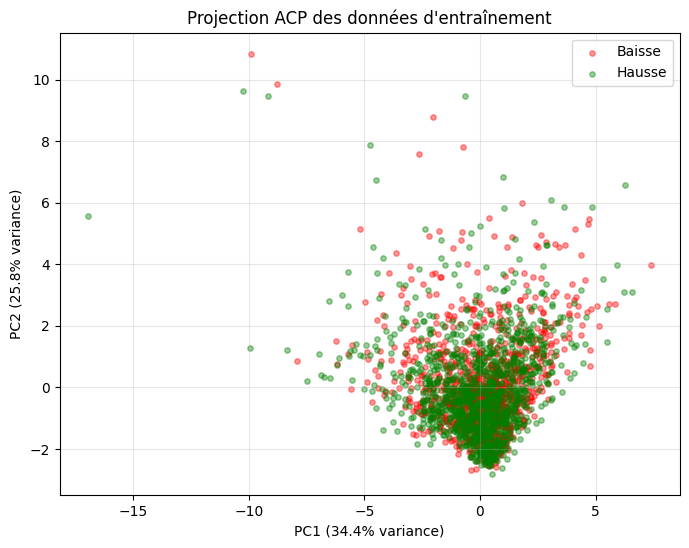

Variance expliquée par les 2 premières composantes : 60.2%


In [56]:
#fait l'ACP
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_sc)

print(X_train_pca)

#affiche l'ACP
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_train_pca[y_train == 0, 0], X_train_pca[y_train == 0, 1],
           c='red', alpha=0.4, s=15, label='Baisse') #point baisse en rouge
ax.scatter(X_train_pca[y_train == 1, 0], X_train_pca[y_train == 1, 1],
           c='green', alpha=0.4, s=15, label='Hausse') # point hausse en vert
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("Projection ACP des données d'entraînement")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print(f"Variance expliquée par les 2 premières composantes : {pca.explained_variance_ratio_.sum():.1%}")

On observe que les classes "hausse" et "baisse" se chevauchent fortement dans l'espace ACP. Il n'y a pas de séparation linéaire évidente, ce qui annonce que les modèles auront probablement du mal à atteindre de bon résultats.

## 7. Modèles

Nous comparons plusieurs modèles, du plus simple au plus complexe :

1. **Baseline naïf** : prédit toujours la classe majoritaire ("hausse")
2. **Régression logistique** : modèle linéaire de référence pour la classification binaire
3. **Régression logistique pénalisée Ridge** ($\ell_2$) : ajoute une pénalité $\lambda \|\beta\|_2^2$
4. **Régression logistique pénalisée Lasso** ($\ell_1$) : ajoute une pénalité $\lambda \|\beta\|_1$ — sélectionne automatiquement les features
5. **K plus proches voisins (KNN)** : modèle non paramétrique

Pour le choix des hyperparamètres ($\lambda$ pour les modèles pénalisés, $k$ pour KNN), on utilise une **validation croisée temporelle** (`TimeSeriesSplit`), qui respecte l'ordre chronologique.

In [57]:
# Validation croisée respectant l'ordre temporel
tscv = TimeSeriesSplit(n_splits=5)

# Dictionnaire pour stocker les résultats des modèles
resultats = {}

### 7.1 Baseline naïf

On prédit toujours la hausse.

In [58]:
classe_majoritaire = int(np.round(y_train.mean()))
y_pred_baseline = np.full_like(y_test, classe_majoritaire)

acc_baseline = accuracy_score(y_test, y_pred_baseline)
print(f"Classe majoritaire : {classe_majoritaire} ({'Hausse' if classe_majoritaire == 1 else 'Baisse'})")
print(f"Accuracy baseline (test) : {acc_baseline:.4f}")

resultats['Baseline'] = acc_baseline

Classe majoritaire : 1 (Hausse)
Accuracy baseline (test) : 0.4966


Un modèle a donc de l'intérêt seulement s'il a une accuracy au moins supérieure à 0.4966.

### 7.2 Régression logistique

**Rappel théorique.** La régression logistique modélise la probabilité d'appartenir à la classe 1 par :
$$ P(y = 1 \mid x) = \sigma(\beta^T x) = \frac{1}{1 + e^{-\beta^T x}} $$

Les paramètres $\beta$ sont estimés en **maximisant la log-vraisemblance**, ce qui revient à **minimiser la log-loss** (entropie croisée binaire) :
$$ \mathcal{L}(\beta) = -\frac{1}{n} \sum_{i=1}^n \left[ y_i \log \sigma(\beta^T x_i) + (1 - y_i) \log(1 - \sigma(\beta^T x_i)) \right] $$

L'optimisation se fait par des méthodes itératives (par défaut **L-BFGS** dans scikit-learn).

In [59]:
logreg = LogisticRegression(penalty=None, max_iter=2000)
logreg.fit(X_train_sc, y_train)

y_pred_logreg = logreg.predict(X_test_sc)
acc_logreg = accuracy_score(y_test, y_pred_logreg)
print(f"Accuracy régression logistique (test) : {acc_logreg:.4f}")

resultats['Logistique'] = acc_logreg

# Coefficients appris
coefs = pd.DataFrame({'feature': FEATURES, 'coef': logreg.coef_[0]})
coefs['|coef|'] = coefs['coef'].abs()
print("\nCoefficients appris (triés par importance) :")
print(coefs.sort_values('|coef|', ascending=False).to_string(index=False))

Accuracy régression logistique (test) : 0.5252

Coefficients appris (triés par importance) :
   feature      coef   |coef|
  return_1 -0.198450 0.198450
ecart_MA20  0.125773 0.125773
 return_10 -0.113139 0.113139
    vol_10 -0.058811 0.058811
    vol_20  0.057765 0.057765
  vol_norm  0.050061 0.050061
  return_5 -0.041835 0.041835
  return_2  0.034815 0.034815
     vol_5  0.027693 0.027693
vol_change  0.003870 0.003870


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


### 7.3 Régression logistique pénalisée Ridge

**Rappel théorique.** Pour limiter le sur-apprentissage et stabiliser les coefficients, on ajoute une pénalité $\ell_2$ :
$$ \hat{\beta} = \arg\min_\beta \; \mathcal{L}(\beta) + \lambda \|\beta\|_2^2 $$

Dans scikit-learn, le paramètre est `C = 1/λ` : un petit `C` correspond à une forte régularisation.

On choisit $\lambda$ par **validation croisée temporelle**.

In [60]:
logreg_ridge = LogisticRegressionCV(
    Cs=np.logspace(-3, 3, 20),
    cv=tscv,
    penalty='l2',
    solver='lbfgs',
    scoring='accuracy',
    max_iter=2000,
)
logreg_ridge.fit(X_train_sc, y_train)

y_pred_ridge = logreg_ridge.predict(X_test_sc)
acc_ridge = accuracy_score(y_test, y_pred_ridge)

print(f"Meilleur C (= 1/λ)  : {logreg_ridge.C_[0]:.4f}")
print(f"Accuracy Ridge (test) : {acc_ridge:.4f}")

resultats['Logistique Ridge'] = acc_ridge

Meilleur C (= 1/λ)  : 0.0043
Accuracy Ridge (test) : 0.5084


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be si

### 7.4 Régression logistique pénalisée Lasso

**Rappel théorique.** La pénalité Lasso utilise la norme $\ell_1$ :
$$ \hat{\beta} = \arg\min_\beta \; \mathcal{L}(\beta) + \lambda \|\beta\|_1 $$

Contrairement à Ridge, Lasso a la propriété intéressante de mettre certains coefficients **exactement à zéro**, ce qui revient à faire une **sélection de variables automatique**.

In [61]:
logreg_lasso = LogisticRegressionCV(
    Cs=np.logspace(-3, 3, 20),
    cv=tscv,
    penalty='l1',
    solver='liblinear',
    scoring='accuracy',
    max_iter=2000,
)
logreg_lasso.fit(X_train_sc, y_train)

y_pred_lasso = logreg_lasso.predict(X_test_sc)
acc_lasso = accuracy_score(y_test, y_pred_lasso)

print(f"Meilleur C (= 1/λ)  : {logreg_lasso.C_[0]:.4f}")
print(f"Accuracy Lasso (test) : {acc_lasso:.4f}")

# Quelles features ont été sélectionnées ?
coefs_lasso = pd.DataFrame({'feature': FEATURES, 'coef': logreg_lasso.coef_[0]})
n_selected = (coefs_lasso['coef'] != 0).sum()
print(f"\nFeatures sélectionnées par Lasso : {n_selected} / {len(FEATURES)}")
print(coefs_lasso[coefs_lasso['coef'] != 0].sort_values('coef', key=abs, ascending=False).to_string(index=False))

resultats['Logistique Lasso'] = acc_lasso

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be si

Meilleur C (= 1/λ)  : 0.0785
Accuracy Lasso (test) : 0.5101

Features sélectionnées par Lasso : 5 / 10
  feature      coef
 return_1 -0.157298
 vol_norm  0.024983
 return_5 -0.002598
    vol_5  0.001334
return_10 -0.000332


### 7.5 K plus proches voisins (KNN)

**Rappel théorique.** Pour prédire la classe d'un nouveau point $x$, KNN cherche les $k$ points les plus proches (au sens de la distance euclidienne) dans le jeu d'entraînement et prédit la classe majoritaire parmi ces voisins.

C'est un modèle **non paramétrique** : il n'apprend pas de paramètres explicites, il stocke simplement les données d'entraînement. Le seul hyperparamètre est $k$, qu'on choisit par validation croisée.

In [62]:
param_grid = {'n_neighbors': [3, 5, 10, 15, 20, 30, 50, 75, 100]}

knn_cv = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=tscv,
    scoring='accuracy',
)
knn_cv.fit(X_train_sc, y_train)

y_pred_knn = knn_cv.predict(X_test_sc)
acc_knn = accuracy_score(y_test, y_pred_knn)

print(f"Meilleur k : {knn_cv.best_params_['n_neighbors']}")
print(f"Accuracy KNN (test) : {acc_knn:.4f}")

resultats['KNN'] = acc_knn

Meilleur k : 100
Accuracy KNN (test) : 0.5017


## 8. Comparaison et choix du modèle final

          Modèle  Accuracy test
      Logistique       0.525168
Logistique Lasso       0.510067
Logistique Ridge       0.508389
             KNN       0.501678
        Baseline       0.496644


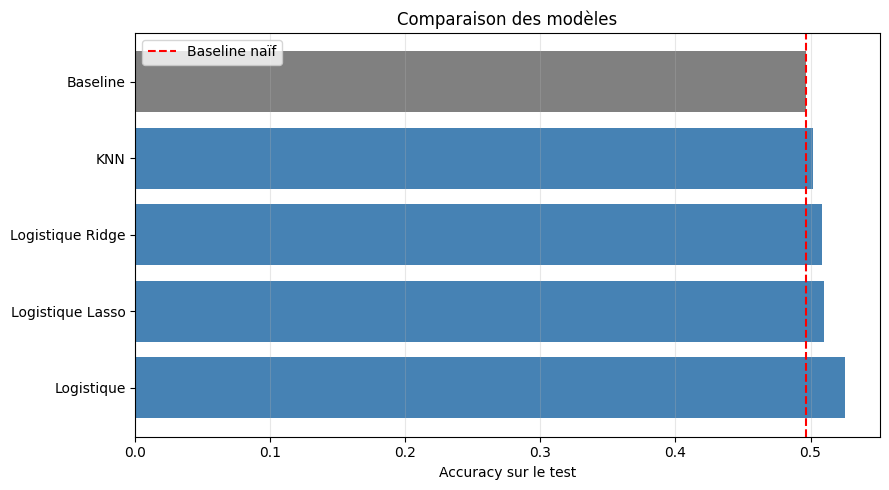

In [63]:
# Récapitulatif des accuracies
df_resultats = pd.DataFrame({
    'Modèle': list(resultats.keys()),
    'Accuracy test': list(resultats.values()),
}).sort_values('Accuracy test', ascending=False).reset_index(drop=True)

print(df_resultats.to_string(index=False))

# Visualisation
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['gray' if m == 'Baseline' else 'steelblue' for m in df_resultats['Modèle']]
ax.barh(df_resultats['Modèle'], df_resultats['Accuracy test'], color=colors)
ax.axvline(acc_baseline, color='red', linestyle='--', label='Baseline naïf')
ax.set_xlabel("Accuracy sur le test")
ax.set_title("Comparaison des modèles")
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Choix du modèle final:** On choisit le modèle qui obtient la meilleure accuracy sur le test.

In [64]:
# Sélection du meilleur modèle (hors baseline)
modeles_dispo = {
    'Logistique': logreg,
    'Logistique Ridge': logreg_ridge,
    'Logistique Lasso': logreg_lasso,
    'KNN': knn_cv.best_estimator_,
}
best_name = max(
    (m for m in resultats if m != 'Baseline'),
    key=lambda m: resultats[m]
)
best_model = modeles_dispo[best_name]
print(f"Modèle final choisi : {best_name}")
print(f"Accuracy test       : {resultats[best_name]:.4f}")

Modèle final choisi : Logistique
Accuracy test       : 0.5252


## 9. Évaluation détaillée du modèle final

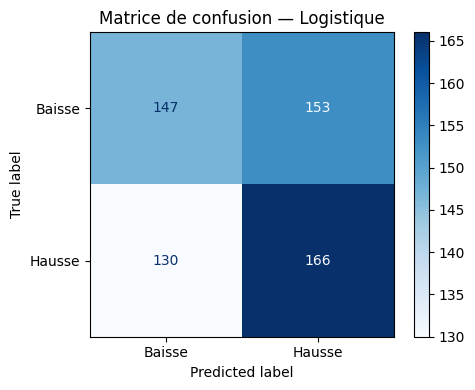


Rapport de classification :
              precision    recall  f1-score   support

      Baisse       0.53      0.49      0.51       300
      Hausse       0.52      0.56      0.54       296

    accuracy                           0.53       596
   macro avg       0.53      0.53      0.52       596
weighted avg       0.53      0.53      0.52       596



In [65]:
y_pred_final = best_model.predict(X_test_sc)

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Baisse', 'Hausse']).plot(ax=ax, cmap='Blues')
ax.set_title(f"Matrice de confusion — {best_name}")
plt.tight_layout()
plt.show()

print("\nRapport de classification :")
print(classification_report(y_test, y_pred_final, target_names=['Baisse', 'Hausse']))

## 10. Test de généralisation sur d'autres cryptomonnaies

Une question intéressante : le modèle entraîné sur Bitcoin se généralise-t-il à d'autres cryptomonnaies ? Si oui, cela suggérerait l'existence de **dynamiques communes** au marché crypto. Si non, chaque actif a sa propre dynamique.

On utilise la bibliothèque `yfinance` pour récupérer les données ETH-USD et SOL-USD. (Si elle n'est pas installée : `pip install yfinance`.)

In [66]:
try:
    import yfinance as yf
    YF_OK = True
except ImportError:
    YF_OK = False
    print("yfinance non installé. Lancer : pip install yfinance")

yfinance non installé. Lancer : pip install yfinance


In [67]:
def telecharger_crypto(ticker, start='2019-01-01', end='2025-01-01'):
    """Télécharge les données journalières d'une crypto et les met au format de notre dataset."""
    raw = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=False)
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)
    raw = raw.reset_index()
    raw = raw.rename(columns={'Date': 'Date'})
    raw['Date'] = pd.to_datetime(raw['Date'])
    return raw[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]

def evaluer_sur_crypto(ticker, modele, scaler, features):
    """Télécharge les données d'une crypto, applique le même feature engineering,
    et évalue le modèle déjà entraîné sur BTC."""
    df_c = telecharger_crypto(ticker)
    df_c = construire_features(df_c).dropna(subset=features + ['y']).reset_index(drop=True)
    Xc = scaler.transform(df_c[features].values)
    yc = df_c['y'].values
    pred = modele.predict(Xc)
    return accuracy_score(yc, pred), yc.mean()

if YF_OK:
    cryptos_test = ['ETH-USD', 'SOL-USD', 'BNB-USD']
    print(f"{'Crypto':<10} {'Accuracy':>10} {'% hausse':>10}")
    print('-' * 32)
    for tk in cryptos_test:
        try:
            acc, taux = evaluer_sur_crypto(tk, best_model, scaler, FEATURES)
            print(f"{tk:<10} {acc:>10.4f} {taux:>10.2%}")
        except Exception as e:
            print(f"{tk:<10} erreur : {e}")

## 11. Discussion et perspectives

(((### Points méthodologiques importants
- **Pas de fuite d'information** : split chronologique, scaler ajusté uniquement sur le train, validation croisée temporelle (`TimeSeriesSplit`).
- **Comparaison à un baseline** : indispensable, sans cela on pourrait croire qu'un modèle à 53% est "bon" alors qu'il fait à peine mieux que prédire toujours la même chose.
- **Évaluation honnête** : on rapporte l'accuracy sur un jeu de test que le modèle n'a jamais vu.)))

### Résultat & interprétation:
Tous nos modèles obtiennent une accuracy proche du baseline naïf (~52-55%). Cela peut paraître décevant, mais c'est en réalité conforme à la littérature financière et à l'hypothèse des marchés efficients (Fama, 1970): si l'on pouvait prédire facilement les rendements futurs à partir du passé, des arbitragistes exploiteraient cette information jusqu'à la faire disparaître.

### Limites

- Limite du dataset Binance (Bastien)

- La manière dont nous avons réalisé le split chronologique pose aussi problème. Nous avons entraîné le modèle sur la période 2018-2024 avec pour objectif de prédire le cours post-2026. Les données d'entraînement sont donc chronologiquement très éloignées des données sur lesquelles on voudrait utiliser le modèle en pratique. Dans le cadre de la prédiction financière, c'est problématique car les données les plus récentes sont les plus représentatives de la manière dont fonctionne le marché actuellement.

- Nous avons utilisé uniquement des données intrinsèques au Bitcoin (prix/volume). Les vrais algorithmes de trading intègrent aussi des données exogènes comme le sentiment collectif (Twitter, news), les décisions politiques, les informations financières extérieures...

- En pratique, même un modèle avec 55 % d'accuracy ne serait pas forcément profitable à cause des coûts de transaction (frais, slippage, spread).

### Pistes d'amélioration
- Tester un horizon intraday (données 1h ou 15min du dataset Kaggle) pour exploiter des fenêtres temporelles moins arbitrées.

- Appliquer le modèle sur une cryptomonnaie secondaire (altcoin), par nature moins efficiente et moins arbitrée.

- Ajouter des indicateurs d'analyse technique en input (RSI, MACD, bandes de Bollinger).

- Donner plus de poids (pondération) aux données les plus récentes lors de l'entraînement pour s'adapter aux dynamiques actuelles du marché.